# Lab 4A – Recurrent Neural Network (RNN) for Sequence Prediction

**Objective:** Implement an RNN model for a sequence prediction task using time-series data, train the model, evaluate prediction performance, and understand how RNNs capture temporal dependencies.

**Dataset:** Synthetic sine-wave time series

This experiment uses a simple sine wave so that students can focus on the working of an RNN without downloading a large dataset.


## 1. Import Required Libraries

We use NumPy for numerical operations, Matplotlib for visualization, and TensorFlow/Keras for building the RNN.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


## 2. Generate Time-Series Data

We create a sine-wave sequence. A sine wave is useful for this experiment because it has a clear repeating pattern.

The RNN will learn the pattern from previous values and use them to predict the next value.


In [2]:
# Create a sequence of time points
time = np.arange(0, 100, 0.1)

# Generate a sine-wave time series
data = np.sin(time)

print("Number of data points:", len(data))
print("First 10 values:", data[:10])


Number of data points: 1000
First 10 values: [0.         0.09983342 0.19866933 0.29552021 0.38941834 0.47942554
 0.56464247 0.64421769 0.71735609 0.78332691]


## 3. Visualize the Time Series

Before training the model, we visualize the data to understand the pattern that the RNN needs to learn.


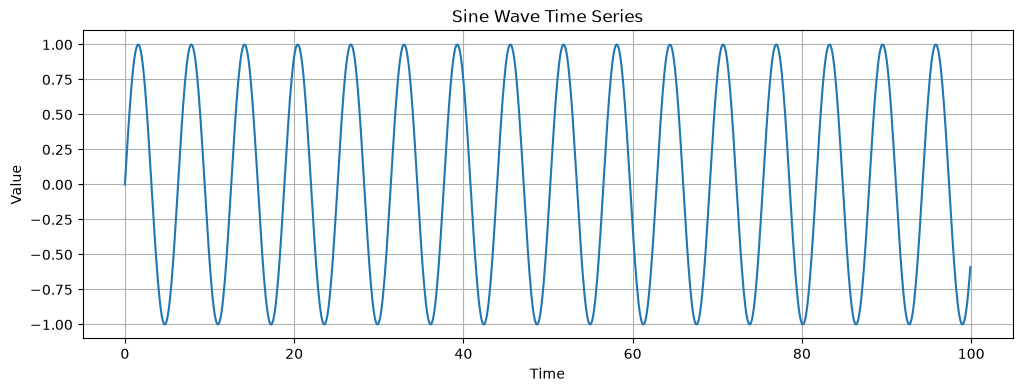

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(time, data)
plt.title("Sine Wave Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


## 4. Create Input Sequences

An RNN expects sequential input. We use the previous **20 values** to predict the next value.

Example:

`[x1, x2, ..., x20] → x21`

`[x2, x3, ..., x21] → x22`

This sliding-window approach converts the time series into supervised learning samples.


In [4]:
# Number of previous time steps used to predict the next value
sequence_length = 20

X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[i:i + sequence_length])
    y.append(data[i + sequence_length])

X = np.array(X)
y = np.array(y)

print("X shape before reshaping:", X.shape)
print("y shape:", y.shape)


X shape before reshaping: (980, 20)
y shape: (980,)


## 5. Split Data into Training and Testing Sets

For time-series data, we keep the order of the observations. Therefore, we do **not** randomly shuffle the data.

The first 80% is used for training and the remaining 20% is used for testing.


In [5]:
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
y_train = y[:split_index]

X_test = X[split_index:]
y_test = y[split_index:]

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 784
Testing samples : 196


## 6. Reshape Data for the RNN

Keras SimpleRNN expects input in the form:

`(samples, time steps, features)`

Here:
- **samples** = number of sequences
- **time steps** = 20 previous values
- **features** = 1 value at each time step


In [6]:
# Add one feature dimension because each time step has one value
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


X_train shape: (784, 20, 1)
X_test shape : (196, 20, 1)


## 7. Build the RNN Model

The model contains:

1. **SimpleRNN layer** – processes the sequence and maintains information from previous time steps.
2. **Dense layer** – produces the final predicted numerical value.

Because this is a regression problem, the output layer has one neuron and does not use softmax.


In [7]:
model = Sequential([
    Input(shape=(sequence_length, 1)),
    SimpleRNN(50, activation="tanh"),
    Dense(1)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile the Model

We use:
- **Adam** optimizer to update the model weights.
- **Mean Squared Error (MSE)** as the loss function because we are predicting a continuous numerical value.
- **Mean Absolute Error (MAE)** as an additional performance metric.


In [8]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully.")


Model compiled successfully.


## 9. Train the RNN

The RNN learns the relationship between previous time steps and the next value.

**Note:** We use a small number of epochs so that the experiment can run quickly in a classroom environment.


In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0359 - mae: 0.1387 - val_loss: 0.0081 - val_mae: 0.0742
Epoch 2/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - mae: 0.0401 - val_loss: 9.9325e-04 - val_mae: 0.0254
Epoch 3/3
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3310e-04 - mae: 0.0150 - val_loss: 1.0598e-04 - val_mae: 0.0083


## 10. Plot Training and Validation Loss

The loss curve helps us understand how the model learns during training.

A decreasing loss generally indicates that the model is learning to make better predictions.


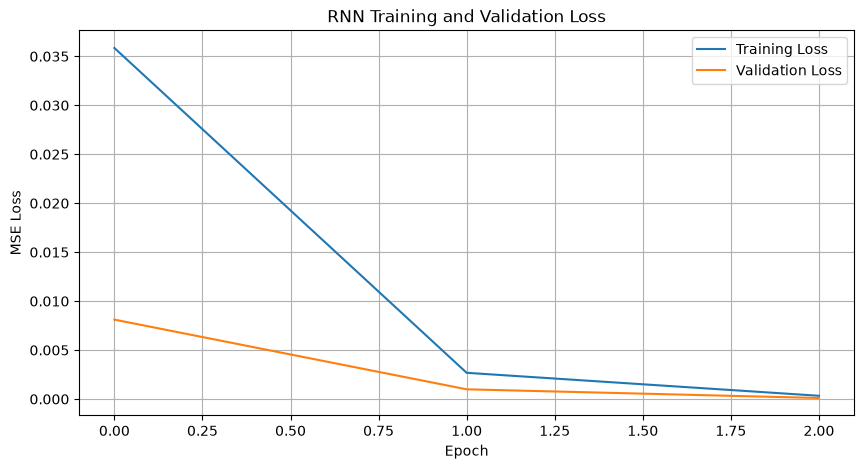

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


## 11. Evaluate the Model on Test Data

The test set contains sequences that were not used to train the model. This gives us an estimate of how well the RNN generalizes to unseen sequential data.


In [11]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

print("Test MSE:", round(test_loss, 6))
print("Test MAE:", round(test_mae, 6))


Test MSE: 0.000113
Test MAE: 0.008672


## 12. Make Predictions

The trained RNN receives the previous 20 time steps and predicts the next value.


In [12]:
y_pred = model.predict(X_test, verbose=0).flatten()

print("First 10 actual values:")
print(y_test[:10])

print("\nFirst 10 predicted values:")
print(y_pred[:10])


First 10 actual values:
[-0.95841889 -0.92514181 -0.88262103 -0.83128139 -0.77163586 -0.70428039
 -0.62988799 -0.54920196 -0.46302849 -0.37222858]

First 10 predicted values:
[-0.95346886 -0.9120183  -0.862638   -0.8078808  -0.74893737 -0.6857931
 -0.61779356 -0.54414934 -0.4642637  -0.3779165 ]


## 13. Calculate Prediction Errors

We calculate MSE and MAE again using the predictions so students can see how prediction errors are measured.


In [13]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 6))
print("Mean Absolute Error (MAE):", round(mae, 6))


Mean Squared Error (MSE): 0.000113
Mean Absolute Error (MAE): 0.008672


## 14. Compare Actual and Predicted Values

The following graph compares the actual time-series values with the values predicted by the RNN.

If the two curves are close to each other, the RNN has learned the sequence pattern reasonably well.


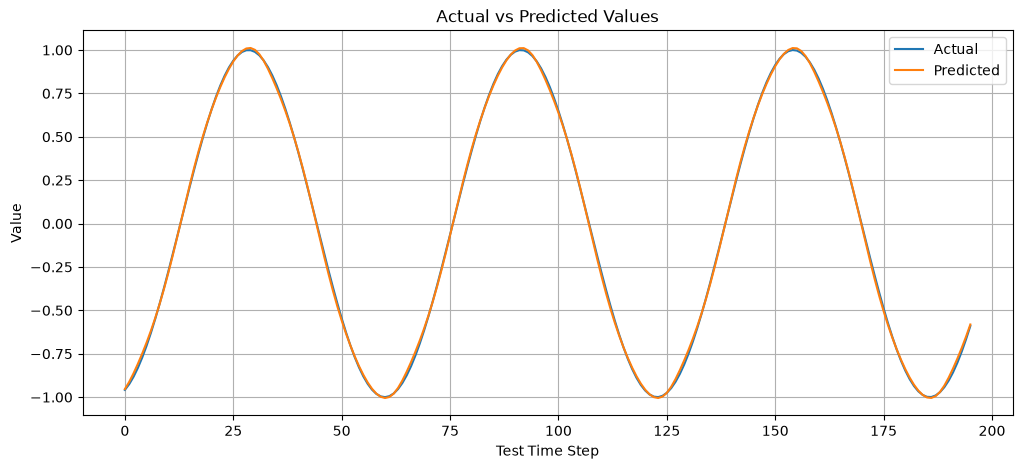

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(y_test[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")
plt.title("Actual vs Predicted Values")
plt.xlabel("Test Time Step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


## 15. Visualize Prediction Error

Prediction error is calculated as:

**Error = Actual Value − Predicted Value**

Values close to zero indicate smaller prediction errors.


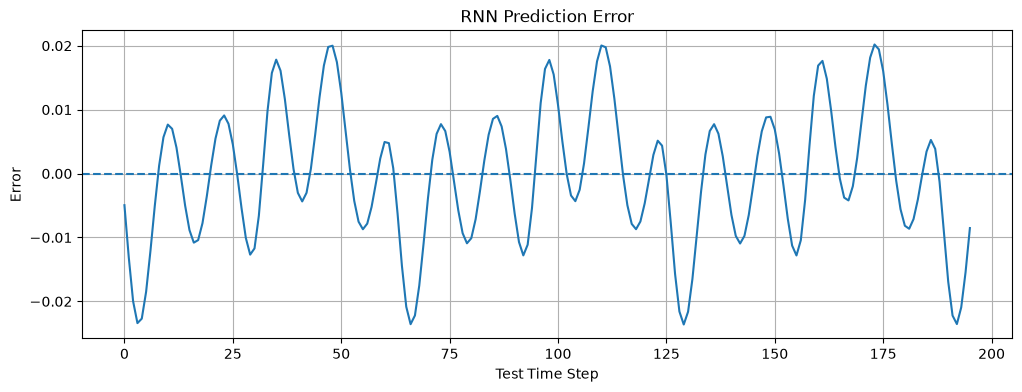

In [15]:
errors = y_test - y_pred

plt.figure(figsize=(12, 4))
plt.plot(errors[:300])
plt.axhline(0, linestyle="--")
plt.title("RNN Prediction Error")
plt.xlabel("Test Time Step")
plt.ylabel("Error")
plt.grid(True)
plt.show()


## 16. Understanding Temporal Dependencies

An important property of an RNN is that it processes data step by step while maintaining a hidden state.

For our experiment:

`Previous values → RNN hidden state → Next prediction`

The model uses information from earlier time steps to make the current prediction. This ability to use information from previous steps is called **temporal dependency**.


### Simple Interpretation

If the predicted curve follows the repeating pattern of the actual sine wave, the RNN has successfully learned useful temporal information from the previous observations.

The experiment demonstrates the basic idea of sequence modeling: **the order of data matters, and previous observations can help predict future observations.**


## 17. Optional Experiment – Change the Sequence Length

Try changing `sequence_length` from **20** to **10** or **40** and retrain the model.

Observe how the amount of historical information provided to the RNN affects prediction performance.

This is a useful way to understand how the amount of sequential context can influence an RNN.


## 18. Final Result

The RNN was successfully implemented for time-series sequence prediction. The model was trained on sequential data and evaluated using MSE and MAE. The actual and predicted values were visualized to analyze prediction performance and understand how an RNN uses previous time steps to capture temporal dependencies.


In [16]:
print("=" * 60)
print("RNN SEQUENCE PREDICTION EXPERIMENT COMPLETED")
print("=" * 60)
print("Test MSE :", round(mse, 6))
print("Test MAE :", round(mae, 6))
print("Sequence length:", sequence_length)
print("The RNN learned temporal patterns from the time-series data.")


RNN SEQUENCE PREDICTION EXPERIMENT COMPLETED
Test MSE : 0.000113
Test MAE : 0.008672
Sequence length: 20
The RNN learned temporal patterns from the time-series data.
